In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
COUNTRY_FILE = RAW_DIR / "GlobalLandTemperaturesByCountry.csv"
GLOBAL_FILE = RAW_DIR / "Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv"

if not COUNTRY_FILE.exists() or not GLOBAL_FILE.exists():
    raise FileNotFoundError(
        f"Could not find input files in {RAW_DIR}. Check your folder structure and notebook working directory."
    )

In [2]:
df_country = pd.read_csv(COUNTRY_FILE)
df_global = pd.read_csv(GLOBAL_FILE)

In [3]:
df_country['dt'] = pd.to_datetime(df_country['dt'])
df_country['Year'] = df_country['dt'].dt.year
df_country['Month'] = df_country['dt'].dt.month
df_country['Country'] = df_country['Country'].astype(str).str.strip()

df_global = df_global.rename(columns={'year': 'Year', 'country': 'Country'})
df_global['Country'] = df_global['Country'].astype(str).str.strip()
df_global['Year'] = pd.to_numeric(df_global['Year'], errors='coerce')
df_country['Year'] = pd.to_numeric(df_country['Year'], errors='coerce')
df_country['AverageTemperature'] = pd.to_numeric(df_country['AverageTemperature'], errors='coerce')
df_country['AverageTemperatureUncertainty'] = pd.to_numeric(df_country['AverageTemperatureUncertainty'], errors='coerce')
value_cols = [c for c in df_global.columns if c not in ['Year', 'Country']]
df_global = df_global.groupby(['Year', 'Country'], as_index=False)[value_cols].mean(numeric_only=True)

df_country_yearly = df_country.groupby(['Year', 'Country'], as_index=False).agg(
    AverageTemperature=('AverageTemperature', 'mean'),
    AverageTemperatureUncertainty=('AverageTemperatureUncertainty', 'mean')
)

In [4]:
df_merged = pd.merge(
    df_country_yearly,
    df_global,
    on=['Year', 'Country'],
    how='inner',
    validate='one_to_one'
)

In [5]:
feature_cols = [c for c in df_global.columns if c not in ['Year', 'Country']]
df_model = df_merged.dropna(subset=['AverageTemperature'] + feature_cols)
df_model = df_model.sort_values(['Country', 'Year']).reset_index(drop=True)

In [6]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
output_file = PROCESSED_DIR / "model_dataset.csv"
df_model.to_csv(output_file, index=False)
print(f"Saved: {output_file}")

Saved: c:\Users\bulba\OneDrive\Desktop\Climate-Change-Predictor\data\processed\model_dataset.csv


In [8]:
print(df_model.head())
print(df_model.shape)
print(df_model.columns.tolist())

   Year    Country  AverageTemperature  AverageTemperatureUncertainty  \
0  1980  Australia           22.586167                       0.171833   
1  1981  Australia           22.164083                       0.195333   
2  1982  Australia           21.910500                       0.164833   
3  1983  Australia           22.261083                       0.197750   
4  1984  Australia           21.516917                       0.182167   

   global_avg_temperature  temperature_anomaly  max_temperature  \
0                 14.7100             0.876667        31.616667   
1                 14.3060             0.854000        37.112000   
2                 14.2375             0.970000        33.567500   
3                 12.7800             1.030000        36.670000   
4                 15.2300             0.910000        29.400000   

   min_temperature  co2_concentration_ppm  annual_rainfall_mm  ...  \
0            4.260                416.990          898.736667  ...   
1            3.240

In [9]:
print("Dataset shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

print("\nData types:")
print(df_model.dtypes)

print("\nMissing values:")
print(df_model.isnull().sum())

Dataset shape: (252, 22)

Columns:
['Year', 'Country', 'AverageTemperature', 'AverageTemperatureUncertainty', 'global_avg_temperature', 'temperature_anomaly', 'max_temperature', 'min_temperature', 'co2_concentration_ppm', 'annual_rainfall_mm', 'sea_level_rise_mm', 'sea_surface_temperature', 'heatwave_days', 'drought_index', 'flood_events_count', 'forest_cover_percent', 'deforestation_rate', 'fossil_fuel_consumption', 'renewable_energy_share', 'air_quality_index', 'predicted_temperature_2050', 'climate_risk_index']

Data types:
Year                               int32
Country                              str
AverageTemperature               float64
AverageTemperatureUncertainty    float64
global_avg_temperature           float64
temperature_anomaly              float64
max_temperature                  float64
min_temperature                  float64
co2_concentration_ppm            float64
annual_rainfall_mm               float64
sea_level_rise_mm                float64
sea_surface_temp

In [10]:
plot_cols = [
    'AverageTemperature',
    'temperature_anomaly',
    'co2_concentration_ppm',
    'annual_rainfall_mm',
    'sea_surface_temperature',
    'sea_level_rise_mm'
]

print(plot_cols)

['AverageTemperature', 'temperature_anomaly', 'co2_concentration_ppm', 'annual_rainfall_mm', 'sea_surface_temperature', 'sea_level_rise_mm']


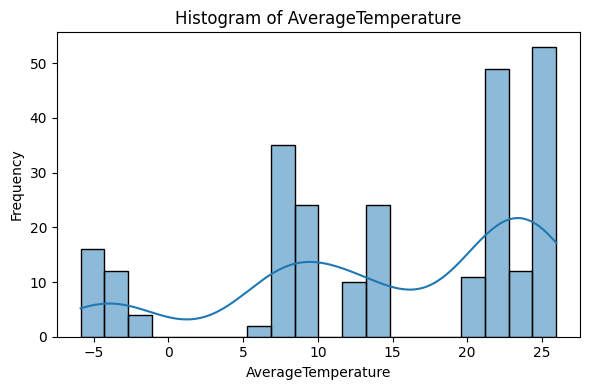

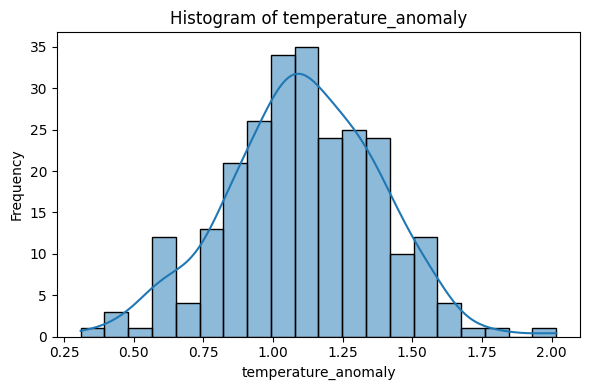

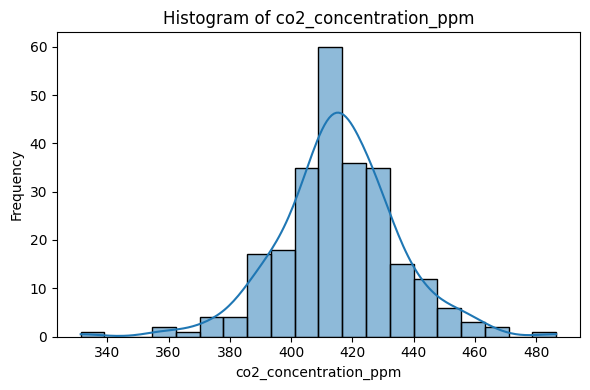

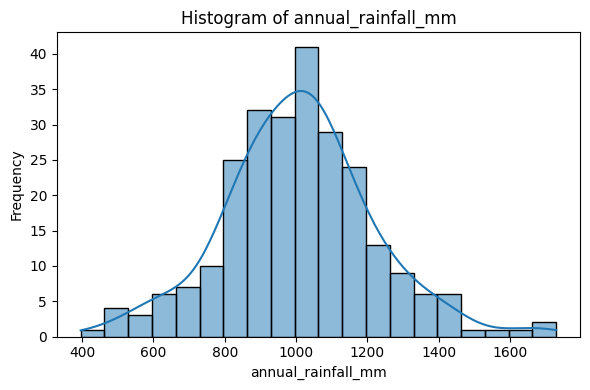

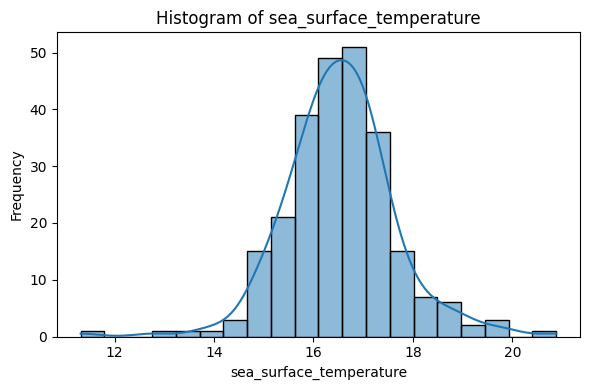

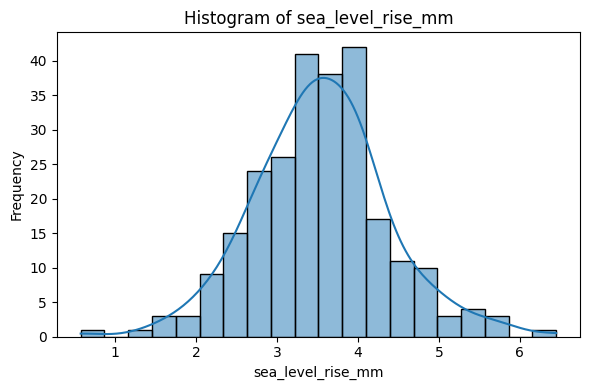

In [11]:
for col in plot_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_model[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

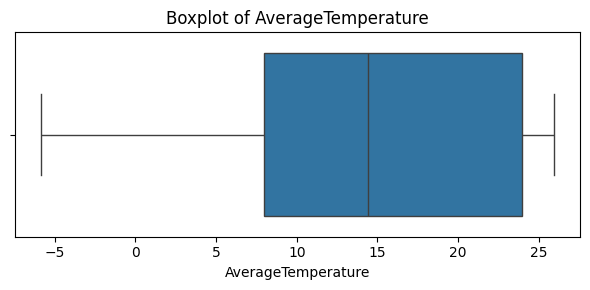

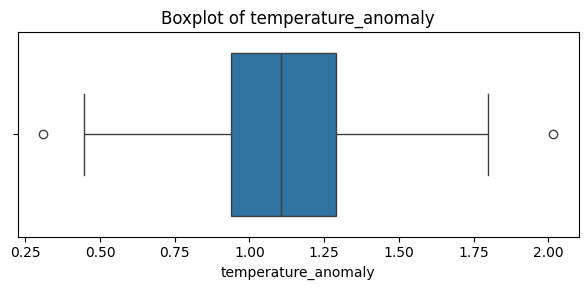

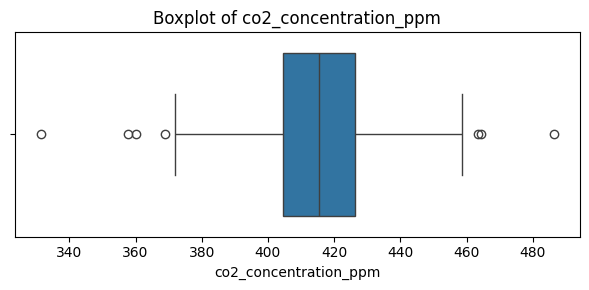

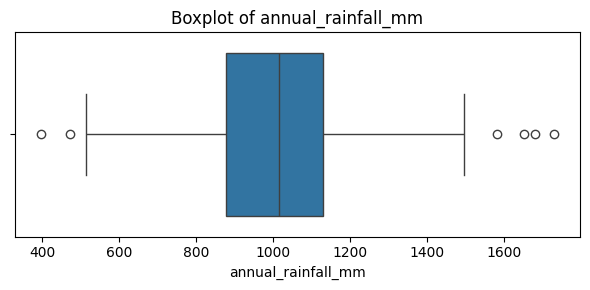

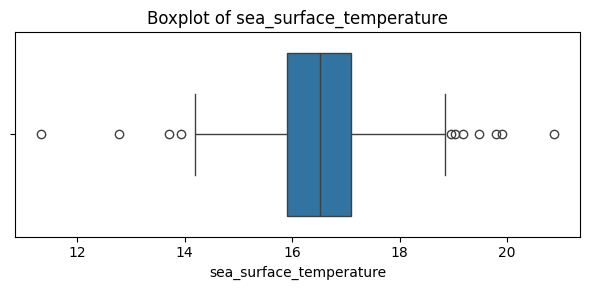

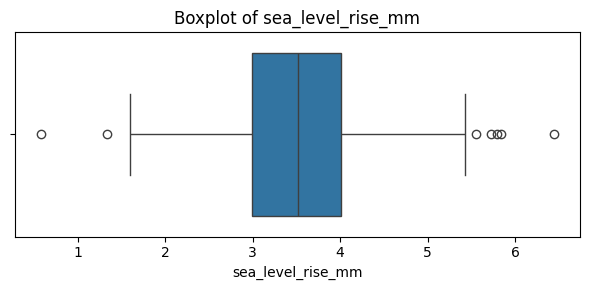

In [12]:
for col in plot_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_model[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [13]:
numeric_cols = [
    'AverageTemperature',
    'AverageTemperatureUncertainty',
    'global_avg_temperature',
    'temperature_anomaly',
    'max_temperature',
    'min_temperature',
    'co2_concentration_ppm',
    'annual_rainfall_mm',
    'sea_level_rise_mm',
    'sea_surface_temperature',
    'heatwave_days',
    'drought_index',
    'flood_events_count',
    'forest_cover_percent',
    'deforestation_rate',
    'fossil_fuel_consumption',
    'renewable_energy_share',
    'air_quality_index',
    'predicted_temperature_2050',
    'climate_risk_index'
]

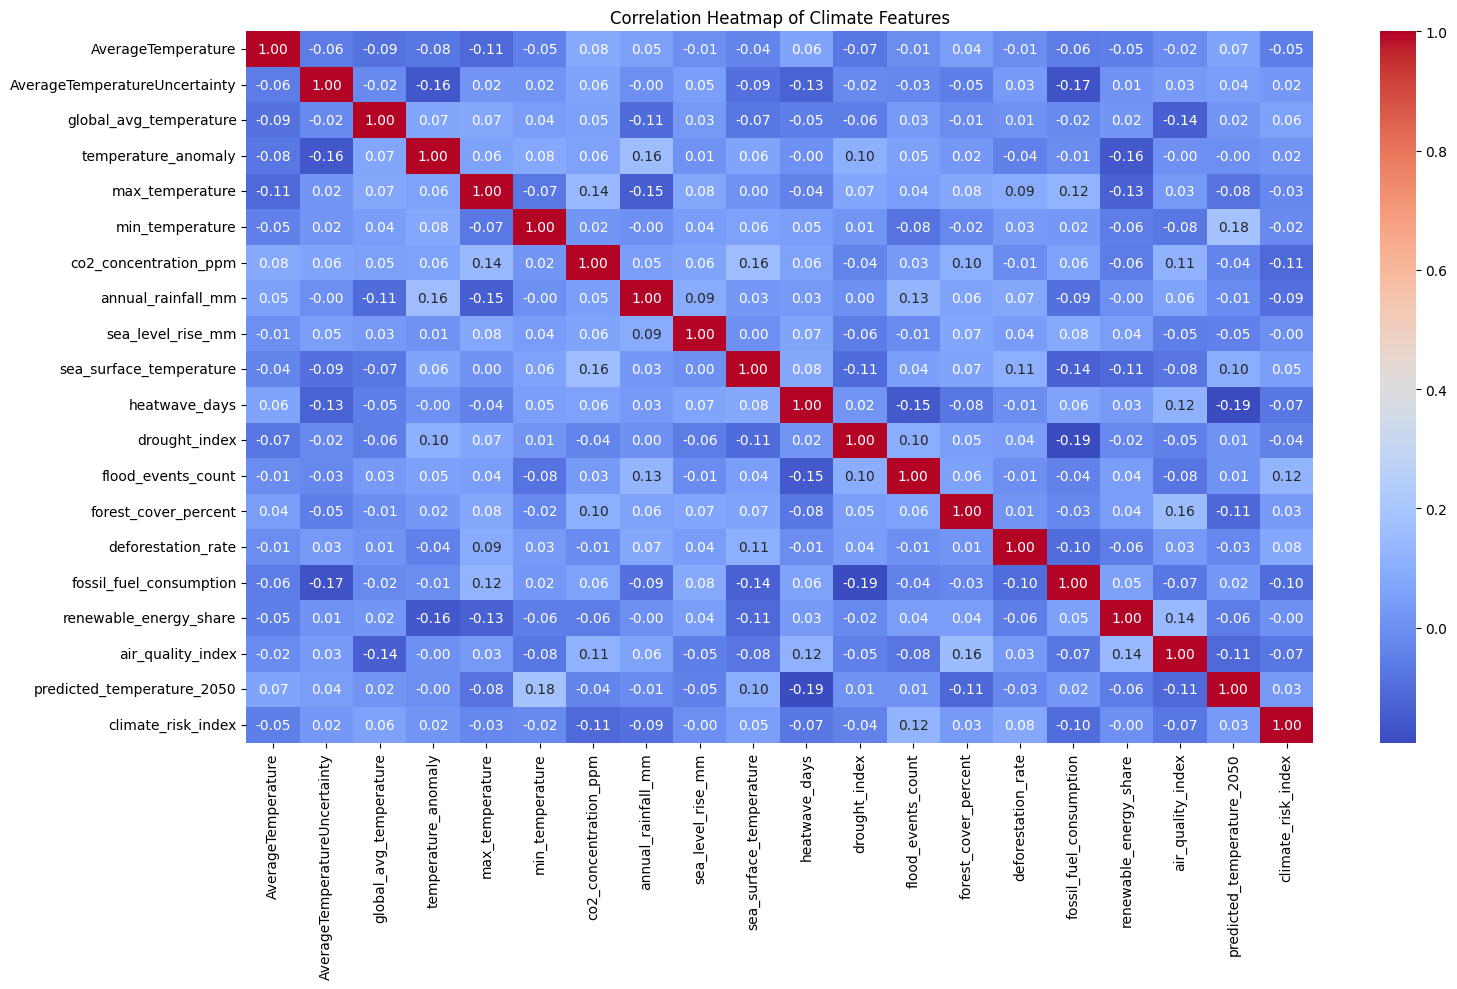

In [14]:
corr_matrix = df_model[numeric_cols].corr()

plt.figure(figsize=(16,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Climate Features")
plt.tight_layout()
plt.show()

In [15]:
pca_features = [
    'AverageTemperatureUncertainty',
    'global_avg_temperature',
    'temperature_anomaly',
    'max_temperature',
    'min_temperature',
    'co2_concentration_ppm',
    'annual_rainfall_mm',
    'sea_level_rise_mm',
    'sea_surface_temperature',
    'heatwave_days',
    'drought_index',
    'flood_events_count',
    'forest_cover_percent',
    'deforestation_rate',
    'fossil_fuel_consumption',
    'renewable_energy_share',
    'air_quality_index',
    'predicted_temperature_2050',
    'climate_risk_index'
]

X = df_model[pca_features]

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

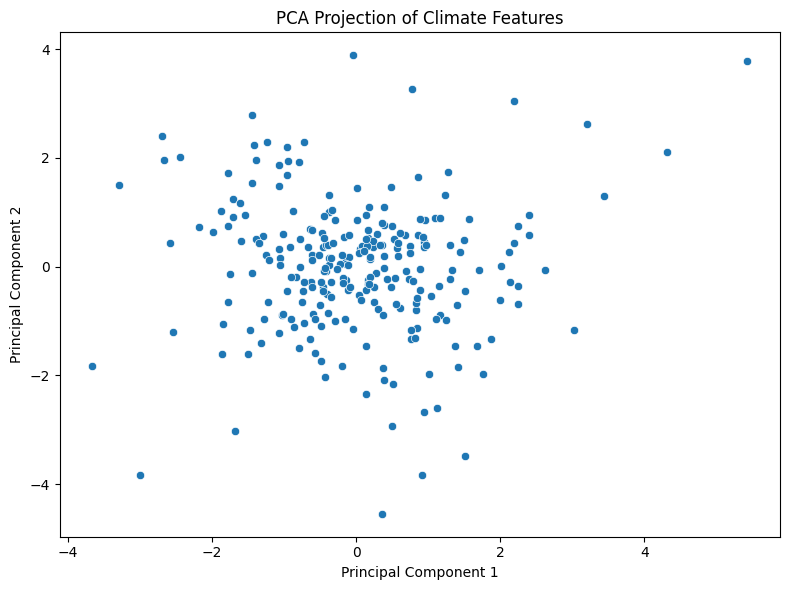

Explained variance ratio: [0.08208533 0.0792927 ]
Total explained variance: 0.16137802792731898


In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title("PCA Projection of Climate Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

In [18]:
#PCA was used to project the climate features into two dimensions. The first two principal components explained 16.14% of the total variance, which is relatively low. This suggests that the climate dataset is complex and cannot be represented well by only two components. The PCA plot did not show strong cluster separation, although some spread and a few potential outliers were visible.